# Prevendo preços do Airbnb no Porto com PyTorch


## 🎯 Objetivos de aprendizagem

Ao final desta aula, você será capaz de

1. **Formular** um problema real de negócio (precificação de imóveis) como um problema de regressão.
2. **Explorar** um dataset real com mais de 15 mil anúncios usando boas práticas de visualização de dados.
3. **Preparar** dados do mundo real (valores ausentes, strings monetárias, outliers via IQR).
4. **Reutilizar** a classe `Architecture` da aula 3b para treinar um modelo de regressão linear em PyTorch com dados reais.
5. **Avaliar** o modelo de forma honesta, comparando com um baseline ingênuo e interpretando o erro em euros.
6. **Salvar, carregar e usar** o modelo treinado para responder à pergunta de um cliente de verdade.

## 🗺️ De onde viemos, para onde vamos

Esta aula é o ponto de encontro de tudo o que construímos até aqui. Nada do que você verá no pipeline é novo. O que muda é uma coisa só, e ela muda tudo. **Os dados agora são reais.**

| Aula | O que construímos | Como aparece hoje |
|------|-------------------|-------------------|
| 02 · Visualizing Gradient Descent | Os 5 passos do gradiente descendente | Escondidos dentro de `train_step_fn` |
| 3a · Rethinking the Training Loop | `Dataset`, `DataLoader`, mini-batches, checkpoints | A seção de preparação de dados |
| 3b · Going Classy | A classe `Architecture` | Copiada **sem alterar uma linha** |
| **04 · Hoje** | **Dados reais do Porto** | EDA, limpeza, avaliação e produção |

Nas aulas anteriores, os dados eram sintéticos. Nós conhecíamos os parâmetros verdadeiros (`b=1`, `w=2`) porque nós mesmos os escolhemos. Hoje ninguém sabe a resposta certa. Bem-vindo ao mundo real. 🌍

# 1. O problema

## 🏠 A pergunta da Dona Amélia

Imagine a seguinte cena. A Dona Amélia herdou um apartamento em **Cedofeita**, no centro histórico do Porto, em Portugal. O imóvel acomoda 4 hóspedes, tem 2 quartos, 2 camas e 1 banheiro. Ela quer anunciá-lo no Airbnb e faz a você, pessoa consultora de dados, a pergunta mais importante do negócio.

> *"Quanto devo cobrar por noite?"*

O **Airbnb** é um marketplace de aluguéis de curta duração. Fundado em 2008, abriu capital em dezembro de 2020 avaliado em cerca de US\$ 47 bilhões e hoje vale mais do que a maioria das redes hoteleiras globais. No Porto, o turismo explodiu na última década e a cidade se tornou um dos destinos mais disputados da Europa. Isso significa milhares de anúncios competindo entre si.

Como o Airbnb é um mercado competitivo, o preço que a Dona Amélia pode cobrar está diretamente ligado à dinâmica de oferta e demanda.

- Preço muito **acima** da média local → hóspedes escolhem alternativas semelhantes e mais baratas.
- Preço muito **abaixo** → ela deixa dinheiro na mesa todas as noites.

## 💡 Estratégia 1 · A média dos vizinhos

Uma abordagem direta seria

1. encontrar anúncios parecidos com o dela,
2. calcular a média de preço desses anúncios,
3. usar esse valor como referência.

Simples e razoável. Guarde essa ideia, pois ela será o nosso **baseline** na Seção 7. Todo modelo de machine learning que construirmos precisa provar que é melhor do que ela. Se não for, a Dona Amélia não precisa de nós. 😅

## 🤖 Estratégia 2 · Machine Learning

Usar dados existentes para prever resultados futuros é a essência do machine learning. No nosso caso, queremos usar os anúncios já publicados no Porto para prever a diária ideal de um imóvel novo.

Nesta aula usaremos uma **regressão linear** implementada em PyTorch. O modelo ajusta uma função matemática aos dados, capturando a relação entre múltiplas variáveis (quartos, hóspedes, banheiros...) e o preço final. Diferente da média simples, a regressão pondera **todas as características ao mesmo tempo** e generaliza para combinações que nunca vimos.

### 🔮 Predict

Antes de olhar qualquer dado, escreva em um papel (sério, escreva!) as suas apostas.

1. Qual variável você acha que **mais** influencia o preço de uma diária no Porto?
2. Qual variável você acha que **quase não** influencia?

Vamos conferir suas apostas na Seção 6. Prever antes de ver é uma das formas mais eficazes de fixar conteúdo. É o chamado *efeito de geração*.

# 2. Conhecendo os dados

O Airbnb não divulga dados oficiais dos anúncios, mas o projeto independente [Inside Airbnb](https://insideairbnb.com/porto/) extrai e publica esses dados para dezenas de cidades. Usaremos o snapshot de **23 de junho de 2026** da região do **Porto, Portugal** ([link direto](https://data.insideairbnb.com/portugal/norte/porto/2026-06-23/data/listings.csv.gz)).

Dois detalhes importantes antes de baixar qualquer coisa.

- O recorte do Inside Airbnb cobre a **região metropolitana**, com 17 municípios (concelhos), incluindo Porto, Vila Nova de Gaia e Matosinhos. Não é só a cidade do Porto.
- Cada linha é um **anúncio** (um imóvel publicado na plataforma), com dezenas de colunas sobre o imóvel, o anfitrião e as avaliações.

In [1]:
# Baixa o dataset apenas se ele ainda não estiver disponível localmente
import os

if not os.path.exists("listings.csv"):
    # wget baixa o arquivo compactado; gunzip -k descompacta mantendo o original
    !wget -q -O listings.csv.gz "https://data.insideairbnb.com/portugal/norte/porto/2026-06-23/data/listings.csv.gz"
    !gunzip -kf listings.csv.gz

print("Arquivo pronto:", os.path.getsize("listings.csv") / 1e6, "MB")

Arquivo pronto: 42.913635 MB


In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv("listings.csv")

print(f"O dataset tem {df.shape[0]:,} anúncios e {df.shape[1]} colunas")
df.head(3)

O dataset tem 15,278 anúncios e 90 colunas


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1690415328002747530,https://www.airbnb.com/rooms/1690415328002747530,20260623040741,2026-06-23,city scrape,Urban Studio,Located on the first floor of a building compl...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,513827895,https://www.airbnb.com/users/show/513827895,1.470311e+18,https://www.airbnb.com/users/profile/147031108...,Mickael,NaN,3.0,1.0,3.0,1.0,NaN,NaN,NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,9.0,NaN,NaN,t,t,NaN,"Cedofeita, Ildefonso, Sé, Miragaia, Nicolau, V...",PORTO,41.145971,-8.603970,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""TV"", ""Air conditioning"", ""Keypad"", ""Washer"",...",$110.00,2026-06-26,2026-06-27,110.0,110.0,"{""quote"": {""taxes"": null, ""currency"": ""EUR"", ""...",1.0,365.0,1.0,4.0,365.0,365.0,1.5,365.0,NaN,t,11,15,27,250,2026-06-23,0,0,0,98,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173698/AL,NaN,9,9,0,0,NaN
1,1584829515078452068,https://www.airbnb.com/rooms/1584829515078452068,20260623040741,2026-06-25,city scrape,Excelente hospedagem,Embrace simplicity in this quiet and well-loca...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,517053071,https://www.airbnb.com/users/show/517053071,1.470326e+18,https://www.airbnb.com/users/profile/147032610...,Roseli Dos Santos,NaN,3.0,0.0,1.0,8.0,NaN,NaN,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/75984...,NaN,1.0,NaN,NaN,t,t,NaN,Mafamude e Vilar do Paraíso,VILA NOVA DE GAIA,41.116059,-8.603115,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Wifi"", ""Kitchen""]",$48.00,2026-06-26,2026-06-27,48.0,48.0,"{""quote"": {""taxes"": null, ""currency"": ""EUR"", ""...",1.0,365.0,1.0,3.0,365.0,365.0,2.8,365.0,NaN,t,25,55,85,360,2026-06-25,2,2,2,185,0,12,576.0,2026-05-31,2026-06-24,5.0,5.0,5.00,5.00,5.00,5.0,5.0,Exempt,NaN,1,0,1,0,2.00
2,30489872,https://www.airbnb.com/rooms/30489872,20260623040741,2026-06-25,city scrape,Citybreak Apartments Coliseu - Superior Studio,"Studio with a double bed, kitchen, bathroom an...",NaN,https://a0.muscache.com/pictures/e34667f6-2792...,2686177,https://www.airbnb.com/users/show/2686177,1.462605e+18,https://www.airbnb.com/users/profile/146260488...,Citybreak,NaN,14.0,0.0,14.0,0.0,"Porto, Portugal",Somos uma empresa de alojamento local no Porto...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/

São **90 colunas**. Ninguém explora 90 colunas de uma vez, e um bom projeto começa **selecionando o que importa para a pergunta**. A pergunta da Dona Amélia envolve as características físicas do imóvel e as regras de reserva, então vamos trabalhar com o seguinte dicionário de dados.

| Coluna | Significado |
|--------|-------------|
| `accommodates` | Quantos hóspedes o imóvel acomoda |
| `bathrooms` | Número de banheiros |
| `bedrooms` | Número de quartos |
| `beds` | Número de camas |
| `minimum_nights` | Mínimo de noites por reserva |
| `maximum_nights` | Máximo de noites por reserva |
| `number_of_reviews` | Total de avaliações recebidas |
| `price` | **Diária em euros (€), o nosso alvo** |

Além dessas, usaremos `latitude`, `longitude`, `room_type` e `neighbourhood_group_cleansed` apenas na exploração visual.

In [3]:
# Visão geral da estrutura: tipos e valores não nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15278 entries, 0 to 15277
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            15278 non-null  int64  
 1   listing_url                                   15278 non-null  object 
 2   scrape_id                                     15278 non-null  int64  
 3   last_scraped                                  15278 non-null  object 
 4   source                                        15278 non-null  object 
 5   name                                          15278 non-null  object 
 6   description                                   14969 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   15273 non-null  object 
 9   host_id                                       15278 non-null 

### 🔍 Três observações de quem lê `info()` com atenção

1. **`price` é `object` (texto), não número.** Vamos descobrir o porquê já já.
2. **Há colunas com muitos valores ausentes.** `bedrooms`, por exemplo, tem milhares de `NaN`.
3. **Algumas colunas vêm 100% vazias neste snapshot** (`host_acceptance_rate`, `instant_bookable`). Dados reais são assim. Datasets mudam de um snapshot para outro, e o seu código precisa sobreviver a isso.

### 🔮 Predict

`df["price"].head()` retorna valores como `$118.00`. Por que será que a coluna de preço vem como **texto**? E que armadilha o símbolo `$` esconde num dataset de Portugal? Pense antes de rodar a próxima célula.

In [6]:
# Uma espiada no alvo: por que 'price' não é numérico?
df["price"].head(8)

,price
0,$110.00
1,$48.00
2,$90.00
3,$96.00
4,$75.78
5,$555.20
6,$521.60
7,NaN


O Inside Airbnb formata o preço com **símbolo de moeda e separador de milhar** (`$1,200.00`), e por isso o pandas lê a coluna como texto. O `$` é só formatação da plataforma. Para o snapshot de Portugal, **os valores estão em euros**.

Para explorar o preço, precisamos convertê-lo em número. Faremos isso em três passos encadeados, removendo a vírgula de milhar, removendo o `$` e convertendo para `float`.

In [7]:
# String -> numero em 3 passos (mesma receita da aula com o Rio de Janeiro)
price_eur = (
    df["price"]
    .str.replace(",", "")            # "$1,200.00" -> "$1200.00"
    .str.replace("$", "")            # "$1200.00"  -> "1200.00"
    .astype(float)                    # "1200.00"   -> 1200.0
)

# Guardamos como nova coluna para usar na exploracao
df["price_eur"] = price_eur

price_eur.describe()

,price
count,13686.000000
mean,152.344046
std,204.586230
min,1.880000
25%,89.242500
50%,118.000000
75%,165.552500
max,10971.710000


### 🔍 Lendo o `describe()` como um profissional

- A **mediana** é ~€118 por noite, e 75% dos anúncios cobram até ~€166.
- O **máximo** passa de €10.000 por noite. 🤯
- A **média** (~€152) é bem maior que a mediana. Quando média >> mediana, a distribuição tem **cauda longa à direita**, puxada por valores extremos.

Esses extremos podem ser mansões de luxo, erros de digitação do anfitrião ou anúncios "vitrine" que nunca são alugados. Seja qual for a causa, eles vão atrapalhar um modelo treinado com MSE, que eleva erros ao quadrado. Voltaremos a isso na Seção 5.

✅ **Check yourself**

1. Se a média é maior que a mediana, a cauda longa está à esquerda ou à direita?
2. Por que um erro de €5.000 pesa muito mais que dez erros de €500 quando a loss é MSE?

# 3. Explorando os dados com boas práticas de visualização

Antes de qualquer modelo, um bom projeto **olha** para os dados. Mas atenção, gráfico bom não é gráfico bonito. Gráfico bom é gráfico que **responde a uma pergunta**. Nesta seção, cada figura começa com a pergunta que ela responde.

Algumas boas práticas que vamos aplicar (e que você deve levar para a vida) 📐

- **Uma pergunta por gráfico.** Se precisa de dois títulos, são dois gráficos.
- **Escala de cor sequencial para magnitude** (claro → escuro) e **divergente para polaridade** (dois tons + neutro no meio). Nunca arco-íris.
- **Eixos e grades discretos**, dados em destaque. A "tinta" deve ir para a informação.
- **Rotule diretamente** o que importa, em vez de forçar o leitor a decodificar legendas.
- **Nunca dois eixos y** no mesmo gráfico.

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Estilo global limpo: grades sutis, sem molduras desnecessarias.
# Definir isso UMA vez evita repetir codigo e mantem as figuras consistentes.
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.8,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlelocation": "left",
})

# Paleta fixa da aula: um azul para dados, um laranja para destaque, cinza para contexto
C_MAIN   = "#2E5E9E"   # azul principal
C_ACCENT = "#D95F02"   # laranja de destaque
C_GRAY   = "#9AA0A6"   # cinza de contexto

## 3.1 · Onde estão os anúncios?

**Pergunta.** Como os anúncios se espalham pela região, e onde estão os mais caros?

Temos `latitude` e `longitude` de cada anúncio. Um gráfico de dispersão desses pares desenha, na prática, um **mapa** da região. Vamos colorir cada ponto pelo preço usando uma escala sequencial (limitada a €300 para os extremos não "achatarem" a escala).

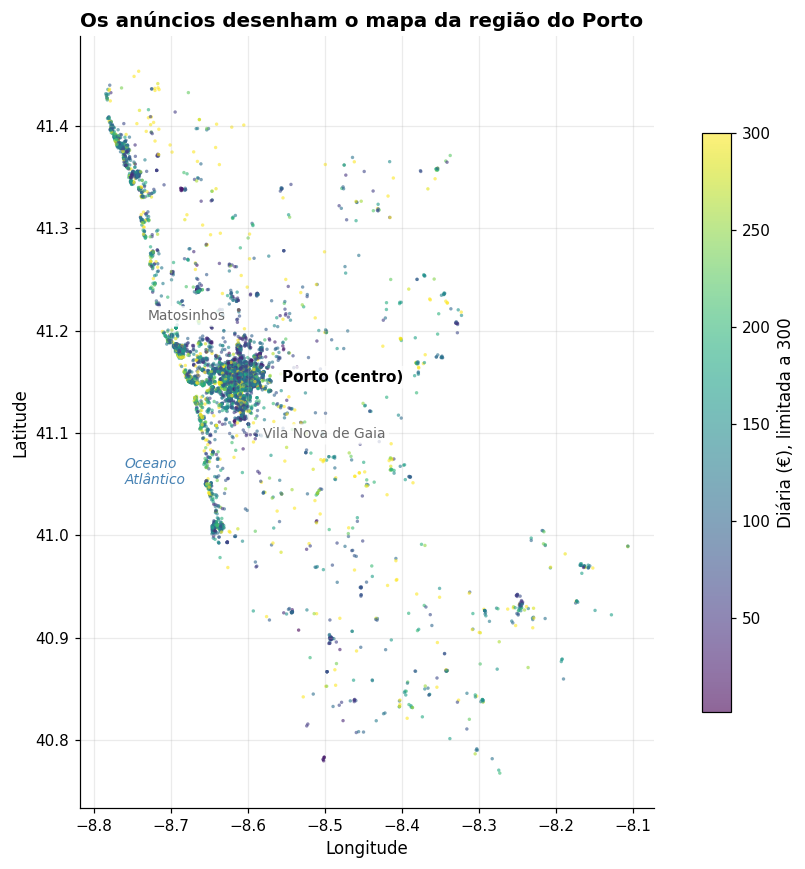

In [9]:
# Cada ponto e um anuncio; a cor codifica o preco (sequencial = magnitude)
geo = df.dropna(subset=["price_eur"])

fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(
    geo["longitude"], geo["latitude"],
    c=geo["price_eur"].clip(upper=300),  # trava a escala em 300 para preservar contraste
    cmap="viridis", s=5, alpha=0.6, linewidths=0,
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.75, label="Diária (€), limitada a 300")

# Rotulos diretos de referencia geografica (melhor que so eixos numericos);
# o fundo branco semitransparente garante leitura sobre a nuvem de pontos
label_box = dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75)
ax.annotate("Porto (centro)", xy=(-8.555, 41.15), fontsize=10, fontweight="bold",
            color="black", bbox=label_box)
ax.annotate("Vila Nova de Gaia", xy=(-8.58, 41.095), fontsize=9, color="dimgray", bbox=label_box)
ax.annotate("Matosinhos", xy=(-8.73, 41.21), fontsize=9, color="dimgray", bbox=label_box)
ax.annotate("Oceano\nAtlântico", xy=(-8.76, 41.05), fontsize=9, color="steelblue", style="italic")

ax.set_title("Os anúncios desenham o mapa da região do Porto")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect(1 / np.cos(np.deg2rad(41.15)))  # corrige a proporcao lon/lat nesta latitude
plt.tight_layout()
plt.show()

### 🔍 O que o mapa nos conta

- A mancha mais densa fica no **centro histórico do Porto** e na margem de **Gaia**, onde ficam as caves de vinho. O rio Douro aparece como um "vazio" serpenteando entre as duas.
- A **orla atlântica** (Foz do Douro, Matosinhos, litoral norte) concentra muitos pontos claros (caros).
- E uma surpresa que derruba a intuição "centro = caro": a diária **mediana** no interior da região é *maior* que a do concelho do Porto (~€150 contra ~€116). O motivo? No interior, a oferta é dominada por casas e quintas inteiras para grupos grandes, enquanto o centro está cheio de estúdios pequenos. Verifique você mesmo com um `groupby("neighbourhood_group_cleansed")`. Dados reais adoram desmentir intuições. 😉

Localização importa, e muito, mas de um jeito **não linear** (caro no litoral, mais barato no anel intermediário, caro de novo no interior rural). Curiosamente, o nosso modelo linear **não usará** latitude/longitude como feature. Guarde essa provocação para os desafios do final.

## 3.2 · Como o preço se distribui?

**Pergunta.** Qual é a "cara" da distribuição do alvo que queremos prever?

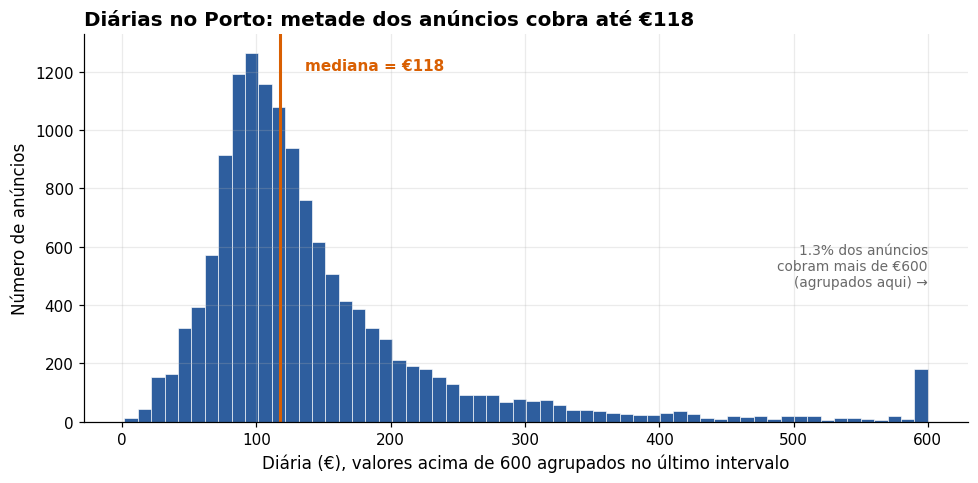

In [10]:
# Histograma do alvo com a mediana rotulada diretamente
prices = df["price_eur"].dropna()
mediana = prices.median()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(prices.clip(upper=600), bins=60, color=C_MAIN, edgecolor="white", linewidth=0.4)
ax.axvline(mediana, color=C_ACCENT, linewidth=2)
ax.annotate(f"mediana = €{mediana:.0f}", xy=(mediana, ax.get_ylim()[1]*0.92),
            xytext=(mediana + 18, ax.get_ylim()[1]*0.92),
            color=C_ACCENT, fontweight="bold", va="center")

pct_600 = (prices > 600).mean() * 100
ax.annotate(f"{pct_600:.1f}% dos anúncios\ncobram mais de €600\n(agrupados aqui) →",
            xy=(600, ax.get_ylim()[1]*0.35), ha="right", fontsize=9, color="dimgray")

ax.set_title("Diárias no Porto: metade dos anúncios cobra até €118")
ax.set_xlabel("Diária (€), valores acima de 600 agrupados no último intervalo")
ax.set_ylabel("Número de anúncios")
plt.tight_layout()
plt.show()

A distribuição é **assimétrica à direita**, exatamente como o `describe()` sugeria. A maioria esmagadora dos anúncios cobra entre €50 e €200, com uma cauda de imóveis premium.

## 3.3 · O tipo de acomodação muda o preço?

**Pergunta.** Quanto varia a diária mediana entre alugar um imóvel inteiro, um quarto privativo ou um quarto compartilhado?

Usamos a **mediana** (e não a média) por ser robusta à cauda longa que acabamos de ver, e barras horizontais porque os nomes das categorias são longos.

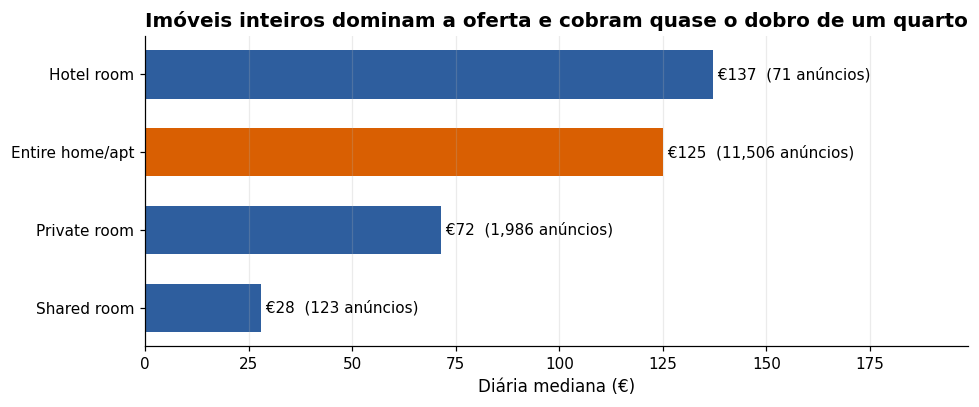

In [11]:
# Mediana por categoria, barras horizontais, rotulos diretos no fim de cada barra
por_tipo = (
    df.dropna(subset=["price_eur"])
      .groupby("room_type")["price_eur"]
      .agg(mediana="median", n="count")
      .sort_values("mediana")
)

fig, ax = plt.subplots(figsize=(9, 3.8))
destaque = ["Entire home/apt"]  # a categoria da Dona Amelia merece destaque
colors = [C_ACCENT if t in destaque else C_MAIN for t in por_tipo.index]

bars = ax.barh(por_tipo.index, por_tipo["mediana"], color=colors, height=0.62)
for bar, (tipo, row) in zip(bars, por_tipo.iterrows()):
    ax.annotate(f" €{row['mediana']:.0f}  ({row['n']:,.0f} anúncios)",
                xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                va="center", fontsize=10)

ax.set_title("Imóveis inteiros dominam a oferta e cobram quase o dobro de um quarto")
ax.set_xlabel("Diária mediana (€)")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, por_tipo["mediana"].max() * 1.45)
plt.tight_layout()
plt.show()

### 🔍 O que aprendemos aqui

- **84% da oferta** da região é de imóveis inteiros (`Entire home/apt`), a categoria da Dona Amélia (em laranja).
- Um imóvel inteiro tem diária mediana de **quase o dobro** de um quarto privativo. O tipo de acomodação carrega muita informação de preço.
- Os quartos de hotel aparecem com a maior mediana, mas são um nicho minúsculo (71 anúncios). Cuidado ao comparar categorias com tamanhos tão diferentes.
- Note o truque de dataviz: a barra da categoria que nos interessa ganhou **cor de destaque**, o resto ficou em cor neutra. O leitor bate o olho e sabe onde olhar.

✅ **Check yourself**

1. Por que usamos a mediana, e não a média, para comparar categorias neste dataset?
2. Por que barras **horizontais** aqui? (Dica: leia os nomes das categorias.)
3. No mapa da Seção 3.1, por que travamos a escala de cor em €300?

# 4. Limpeza e preparação para o modelo

Hora de montar a tabela que alimentará o modelo. Seguiremos o roteiro: **selecionar colunas → tratar ausentes → remover outliers**.

In [12]:
# Selecionamos apenas as colunas relevantes do dataframe original 'df'
target_columns = [
    "accommodates",      # Hospedes que o imovel acomoda
    "bathrooms",         # Banheiros
    "bedrooms",          # Quartos
    "beds",              # Camas
    "minimum_nights",    # Minimo de noites por reserva
    "maximum_nights",    # Maximo de noites por reserva
    "number_of_reviews", # Total de avaliacoes recebidas
    "price",             # Diaria (alvo) -- ainda como string!
]

# .copy() cria um dataframe independente, e nao apenas uma "view" do original
porto_listings = df[target_columns].copy()

porto_listings.sample(5, random_state=42)

,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,number_of_reviews,price
6872,2,1.0,1.0,1.0,1.0,1125.0,4,NaN
9205,2,1.0,1.0,1.0,1.0,365.0,4,NaN
11778,4,2.0,2.0,2.0,2.0,1125.0,0,$136.50
7712,8,2.0,3.0,4.0,1.0,365.0,66,$205.00
4553,2,1.0,1.0,1.0,1.0,365.0,16,$69.14


In [13]:
# Convertendo o alvo para numero (mesma receita da Secao 2)
porto_listings["price"] = (
    porto_listings["price"]
    .str.replace(",", "")
    .str.replace("$", "")
    .astype(float)
)

# Quantos valores ausentes ha em cada coluna?
porto_listings.isna().sum().sort_values(ascending=False)

,0
bedrooms,2797
bathrooms,1703
price,1592
beds,1078
maximum_nights,2
minimum_nights,2
accommodates,0
number_of_reviews,0


### 🤔 O dilema dos valores ausentes

`bedrooms` não é preenchido em milhares de anúncios, e `price` em outros tantos. Temos duas saídas clássicas.

1. **Descartar** as linhas incompletas (`dropna`). Simples, mas joga dados fora.
2. **Imputar** os valores (média, mediana, modelos). Mantém os dados, mas inventa informação.

Nesta aula seguiremos com `dropna`, a mesma escolha da versão do Rio, priorizando a simplicidade. Num projeto real você testaria as duas e mediria o impacto. O ponto essencial é **saber o que se perde**, e é isso que a próxima célula quantifica.

In [14]:
antes = len(porto_listings)
porto_listings.dropna(axis=0, inplace=True)
depois = len(porto_listings)

print(f"Linhas antes:  {antes:,}")
print(f"Linhas depois: {depois:,}")
print(f"Perdemos {antes - depois:,} linhas ({(antes - depois) / antes:.1%} do dataset)")

Linhas antes:  15,278
Linhas depois: 10,521
Perdemos 4,757 linhas (31.1% do dataset)


## 4.1 · Removendo outliers com a regra do IQR

Lembra da diária de €10.000? Com a loss MSE, um único anúncio desses domina o gradiente e distorce o modelo inteiro. Vamos filtrar valores extremos com a **regra de Tukey**, baseada no intervalo interquartil (IQR).

$$\text{IQR} = Q_3 - Q_1 \qquad \text{mantemos } x \in [\,Q_1 - 1.5\cdot\text{IQR},\; Q_3 + 1.5\cdot\text{IQR}\,]$$

É a mesma regra que desenha os "bigodes" de um boxplot. O multiplicador `k=1.5` é o padrão histórico; `k=3.0` seria mais tolerante. As funções abaixo são **idênticas** às da versão do Rio. Código bom se reaproveita.

### 🔮 Predict

Temos ~10,5 mil linhas e vamos aplicar o filtro em **todas as 8 colunas ao mesmo tempo** (uma linha sobrevive apenas se for "normal" em todas). Anote seu palpite: quantas linhas sobrarão?

In [15]:
def _iqr_bounds(series: pd.Series, k: float = 1.5):
    """
    Calcula os limites inferior/superior para deteccao de outliers pela regra do IQR.

    Parameters
    ----------
    series : pd.Series
        Serie numerica.
    k : float, default 1.5
        Multiplicador do "bigode" (1.5 = Tukey; 3.0 = mais tolerante).

    Returns
    -------
    low : float
        Limite inferior (Q1 - k * IQR).
    up : float
        Limite superior (Q3 + k * IQR).
    stats : dict
        Dicionario com Q1, Q3 e IQR.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    up = q3 + k * iqr
    return low, up, {"Q1": q1, "Q3": q3, "IQR": iqr}


def remove_outliers_iqr(
    df: pd.DataFrame,
    columns: list[str],
    k: float = 1.5,
    inclusive: bool = True,
    dropna: bool = True,
):
    """
    Remove linhas com outliers, coluna a coluna, usando a regra do IQR.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame de entrada.
    columns : list of str
        Colunas avaliadas (numericas ou conversiveis).
    k : float, default 1.5
        Multiplicador do bigode (1.5 = padrao; 3.0 = tolerante).
    inclusive : bool, default True
        Se True, mantem valores exatamente sobre os limites.
    dropna : bool, default True
        Se True, descarta NaN nas colunas selecionadas antes do filtro.

    Returns
    -------
    cleaned : pd.DataFrame
        DataFrame sem as linhas com outliers.
    info : dict
        Resumo com contagens e limites/estatisticas por coluna.
    """
    data = df.copy()

    # Garante colunas numericas; valores nao numericos viram NaN
    for c in columns:
        data[c] = pd.to_numeric(data[c], errors="coerce")

    if dropna:
        data = data.dropna(subset=columns)

    before = len(data)
    bounds = {}
    # Comeca com todas as linhas validas e refina com a mascara de cada coluna
    mask = pd.Series(True, index=data.index)

    for c in columns:
        low, up, stats = _iqr_bounds(data[c].dropna(), k=k)
        bounds[c] = {"low": low, "up": up, **stats}

        if inclusive:
            m = (data[c] >= low) & (data[c] <= up)
        else:
            m = (data[c] > low) & (data[c] < up)

        mask &= m

    cleaned = data.loc[mask].copy()
    info = {
        "rows_in": before,
        "rows_out": len(cleaned),
        "rows_removed": before - len(cleaned),
        "k": k,
        "inclusive": inclusive,
        "bounds": bounds,
    }
    return cleaned, info

In [16]:
# Aplica o filtro IQR (regra de Tukey, k=1.5, limites inclusivos)
porto_iqr, summary = remove_outliers_iqr(
    df=porto_listings,
    columns=target_columns,
    k=1.5,
    inclusive=True,
    dropna=True,
)

print(f"Linhas antes:   {summary['rows_in']:,}")
print(f"Linhas depois:  {summary['rows_out']:,}")
print(f"Removidas:      {summary['rows_removed']:,}")
print("\nLimites por coluna (low/up):")
for col, b in summary["bounds"].items():
    print(f"  - {col}: [{b['low']:.2f}, {b['up']:.2f}]  (Q1={b['Q1']:.2f}, Q3={b['Q3']:.2f}, IQR={b['IQR']:.2f})")

Linhas antes:   10,521
Linhas depois:  8,114
Removidas:      2,407

Limites por coluna (low/up):
  - accommodates: [-2.50, 9.50]  (Q1=2.00, Q3=5.00, IQR=3.00)
  - bathrooms: [-0.50, 3.50]  (Q1=1.00, Q3=2.00, IQR=1.00)
  - bedrooms: [-0.50, 3.50]  (Q1=1.00, Q3=2.00, IQR=1.00)
  - beds: [-2.00, 6.00]  (Q1=1.00, Q3=3.00, IQR=2.00)
  - minimum_nights: [-0.50, 3.50]  (Q1=1.00, Q3=2.00, IQR=1.00)
  - maximum_nights: [-1012.50, 2407.50]  (Q1=270.00, Q3=1125.00, IQR=855.00)
  - number_of_reviews: [-131.50, 232.50]  (Q1=5.00, Q3=96.00, IQR=91.00)
  - price: [-28.00, 300.00]  (Q1=95.00, Q3=177.00, IQR=82.00)


Seu palpite chegou perto? Repare que o corte mais agressivo **não** veio do preço. Colunas como `minimum_nights` e `number_of_reviews` também têm caudas longas e eliminam muitas linhas. Filtrar outliers em várias colunas simultaneamente é sempre mais destrutivo do que parece.

Vamos **ver** o efeito do filtro no alvo. Comparações antes/depois pedem os mesmos eixos, lado a lado.

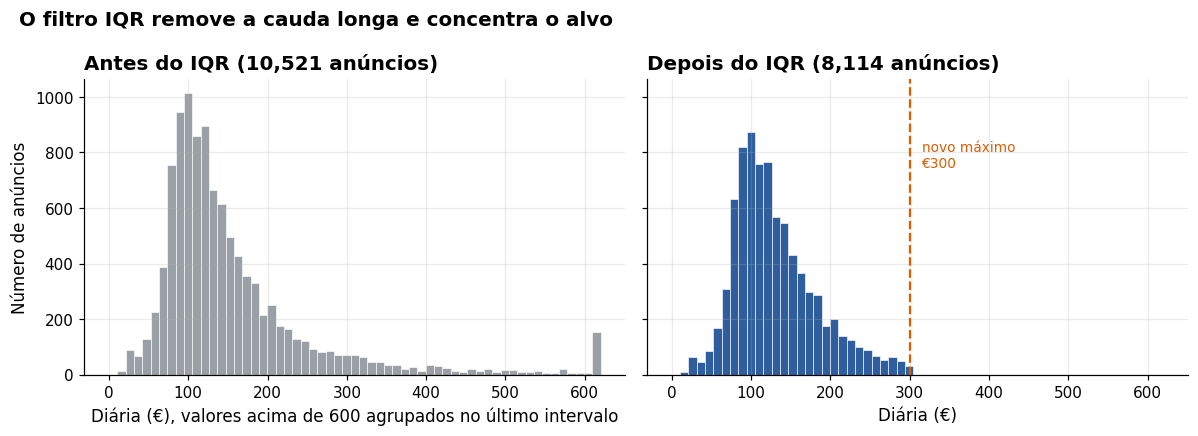

In [17]:
# Antes vs depois do IQR no alvo, com eixos identicos para comparacao justa
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

bins = np.linspace(0, 620, 60)
axes[0].hist(porto_listings["price"].clip(upper=610), bins=bins, color=C_GRAY,
             edgecolor="white", linewidth=0.4)
axes[0].set_title(f"Antes do IQR ({len(porto_listings):,} anúncios)")
axes[0].set_xlabel("Diária (€), valores acima de 600 agrupados no último intervalo")
axes[0].set_ylabel("Número de anúncios")

axes[1].hist(porto_iqr["price"], bins=bins, color=C_MAIN,
             edgecolor="white", linewidth=0.4)
axes[1].set_title(f"Depois do IQR ({len(porto_iqr):,} anúncios)")
axes[1].set_xlabel("Diária (€)")

max_price = porto_iqr["price"].max()
axes[1].axvline(max_price, color=C_ACCENT, linewidth=1.5, linestyle="--")
axes[1].annotate(f"novo máximo\n€{max_price:.0f}", xy=(max_price, axes[1].get_ylim()[1]*0.7),
                 xytext=(max_price + 15, axes[1].get_ylim()[1]*0.7), color=C_ACCENT, fontsize=9)

fig.suptitle("O filtro IQR remove a cauda longa e concentra o alvo", x=0.02, ha="left",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
# Estatisticas finais do alvo que o modelo vai aprender
porto_iqr["price"].describe()

,price
count,8114.000000
mean,130.397188
std,52.062474
min,16.000000
25%,93.000000
50%,120.000000
75%,158.000000
max,300.000000


Ficamos com um alvo bem-comportado, com diárias entre o mínimo e ~€300 e mediana em torno de €120. É **este** recorte de mercado que o nosso modelo aprenderá. Importante ser honesto no relatório final: o modelo resultante não serve para precificar mansões de luxo, pois nós as removemos do treino.

✅ **Check yourself**

1. O que significa `k=1.5` na regra de Tukey? O que mudaria com `k=3.0`?
2. Por que o filtro em 8 colunas remove mais linhas do que o filtro apenas em `price`?
3. Que tipo de imóvel o nosso modelo **não** saberá precificar depois desse filtro?

# 5. Quais variáveis importam? Correlação

Antes de treinar, vamos medir a **correlação de Pearson** entre cada par de variáveis. Ela varia de -1 a +1 e captura relações **lineares**. Como nosso modelo é linear, essa é exatamente a lente certa. 🔎

In [19]:
# Matriz de correlacao de Pearson e ranking em relacao ao alvo
corr_matrix = porto_iqr.corr(method="pearson")

price_corr = corr_matrix["price"].drop("price").sort_values(ascending=False)

print("Correlação das features com o alvo 'price':\n")
print(price_corr.round(3))

Correlação das features com o alvo 'price':

bedrooms             0.503
accommodates         0.500
beds                 0.398
bathrooms            0.379
maximum_nights       0.058
minimum_nights      -0.003
number_of_reviews   -0.015
Name: price, dtype: float64


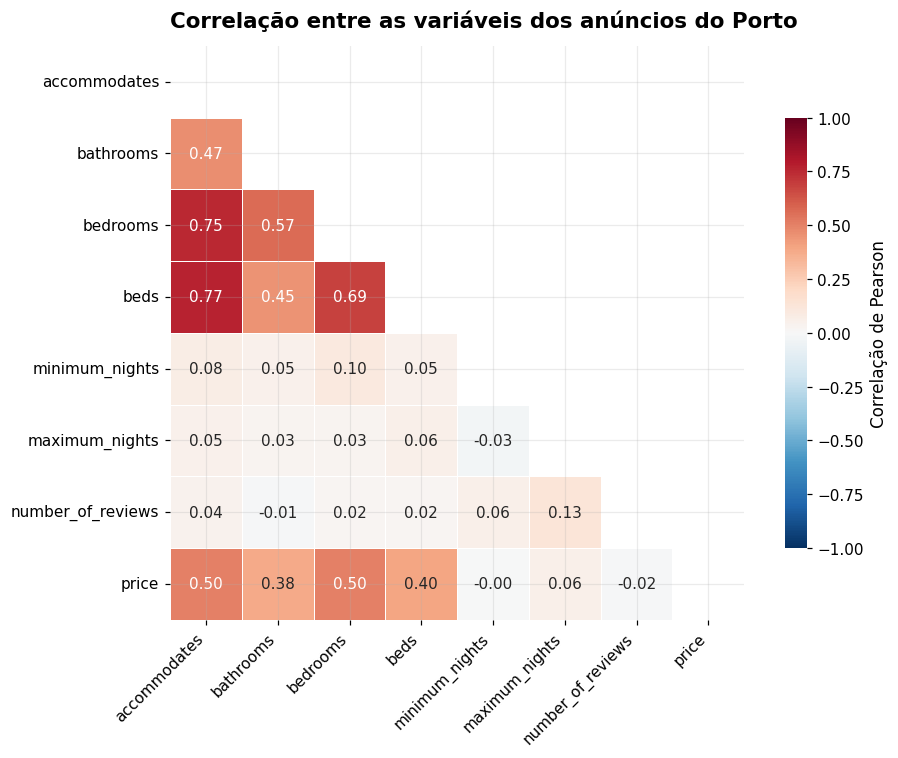

In [20]:
import seaborn as sns

# Heatmap so com o triangulo inferior: a matriz e simetrica,
# mostrar as duas metades duplica tinta sem acrescentar informacao
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,           # anota o valor em cada celula
    fmt=".2f",
    cmap="RdBu_r",        # divergente: azul = negativo, vermelho = positivo
    center=0,             # neutro (branco) exatamente no zero
    vmin=-1, vmax=1,      # escala completa e simetrica
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75, "label": "Correlação de Pearson"},
)
plt.title("Correlação entre as variáveis dos anúncios do Porto", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 🔍 Hora de conferir as apostas da Seção 1

- **`bedrooms` e `accommodates` (~0.50)** lideram com folga: quanto maior o imóvel, maior a diária. Era a sua aposta?
- **`beds` e `bathrooms` (~0.38-0.40)** vêm logo atrás, e note no heatmap que elas são fortemente correlacionadas **entre si** e com `accommodates` (0.45 a 0.77). Elas contam histórias parecidas, um fenômeno chamado **multicolinearidade**.
- **`minimum_nights`, `maximum_nights` e `number_of_reviews` (~0.0)** praticamente não têm relação linear com o preço.

Duas leituras erradas que você deve evitar 🚨

1. Correlação **não é** causalidade. Adicionar um banheiro não "causa" +€40 na diária.
2. Correlação ~0 significa ausência de relação **linear**. Pode existir relação não linear que o Pearson não enxerga.

✅ **Check yourself**

1. Sem olhar de novo: quais são as duas variáveis mais correlacionadas com o preço no Porto?
2. Por que mascaramos o triângulo superior do heatmap?
3. O que é multicolinearidade e onde ela aparece neste dataset?

# 6. Pipeline de ponta a ponta em PyTorch

Chegou a hora de aplicar **tudo** o que construímos nas aulas 02, 3a e 3b. O plano segue as mesmas quatro etapas de sempre.

1. **Preparação dos dados** → tensores, split treino/validação, padronização, `DataLoader`
2. **Configuração do modelo** → modelo linear, loss MSE, otimizador SGD
3. **Treinamento** → a classe `Architecture` cuida do loop
4. **Avaliação e produção** → Seções 7 e 8

E os 5 passos do gradiente descendente da aula 02? Continuam todos aqui, escondidos dentro de `_make_train_step_fn`: forward pass → loss → gradientes → atualização → repete. A classe apenas os organiza.

## 6.1 · Imports

In [21]:
import numpy as np
import datetime
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, TensorDataset, DataLoader, Subset
from torch.utils.data.dataset import random_split
import torch.optim as optim
import torch.nn as nn
%matplotlib inline

## 6.2 · Reencontro com a classe `Architecture`

A célula abaixo é a classe da **aula 3b, sem alterar uma linha**. Esse é o superpoder do "Going Classy": o código de treino não sabe (nem precisa saber) se os dados são pontos sintéticos de uma reta ou 8 mil apartamentos no Porto.

Releia os métodos com olhos de revisão. Se algum deles parecer estranho, volte à aula 3b antes de continuar.

In [22]:
class Architecture(object):
    def __init__(self, model, loss_fn, optimizer):
        # Aqui definimos os atributos da nossa classe

        # Comecamos armazenando os argumentos como atributos
        # para usa-los mais tarde
        self.model = model
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        # Ja enviamos o modelo para o dispositivo escolhido
        self.model.to(self.device)

        # Estes atributos sao definidos aqui, mas como nao sao informados
        # no momento da criacao, ficam como None
        self.train_loader = None
        self.val_loader = None

        # Estes atributos serao calculados internamente
        self.losses = []
        self.val_losses = []
        self.total_epochs = 0

        # Cria a funcao train_step para o modelo, loss e otimizador
        # Atencao: NAO ha argumentos! Ela usa diretamente os atributos da classe
        self.train_step_fn = self._make_train_step_fn()
        # Cria a funcao val_step para o modelo e a loss
        self.val_step_fn = self._make_val_step_fn()

    def to(self, device):
        # Permite ao usuario especificar outro dispositivo
        # Atualiza o atributo correspondente e envia o modelo para la
        try:
            self.device = device
            self.model.to(self.device)
        except RuntimeError:
            self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
            print(f"Couldn't send it to {device}, sending it to {self.device} instead.")
            self.model.to(self.device)

    def set_loaders(self, train_loader, val_loader=None):
        # Permite ao usuario definir qual train_loader (e val_loader, opcional) usar
        # Ambos sao atribuidos a atributos da classe para referencia posterior
        self.train_loader = train_loader
        self.val_loader = val_loader

    def _make_train_step_fn(self):
        # Este metodo nao precisa de argumentos: usa os atributos
        # self.model, self.loss_fn e self.optimizer

        # Constroi a funcao que executa um passo do loop de treino
        def perform_train_step_fn(x, y):
            # Coloca o modelo em modo TRAIN
            self.model.train()

            # Passo 1 - calcula a previsao do modelo (forward pass)
            yhat = self.model(x)
            # Passo 2 - calcula a loss
            loss = self.loss_fn(yhat, y)
            # Passo 3 - calcula os gradientes dos parametros
            loss.backward()
            # Passo 4 - atualiza os parametros usando gradientes e learning rate
            self.optimizer.step()
            self.optimizer.zero_grad()

            # Retorna a loss
            return loss.item()

        # Retorna a funcao que sera chamada dentro do loop de treino
        return perform_train_step_fn

    def _make_val_step_fn(self):
        # Constroi a funcao que executa um passo do loop de validacao
        def perform_val_step_fn(x, y):
            # Coloca o modelo em modo EVAL
            self.model.eval()

            # Passo 1 - calcula a previsao do modelo (forward pass)
            yhat = self.model(x)
            # Passo 2 - calcula a loss
            loss = self.loss_fn(yhat, y)
            # Nao ha passos 3 e 4: parametros nao sao atualizados na validacao
            return loss.item()

        return perform_val_step_fn

    def _mini_batch(self, validation=False):
        # O mini-batch funciona com ambos os loaders
        # O argumento `validation` define o loader e a step function usados
        if validation:
            data_loader = self.val_loader
            step_fn = self.val_step_fn
        else:
            data_loader = self.train_loader
            step_fn = self.train_step_fn

        if data_loader is None:
            return None

        # Definidos o loader e a step function, este e o mesmo
        # loop de mini-batches de antes
        mini_batch_losses = []
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.to(self.device)

            mini_batch_loss = step_fn(x_batch, y_batch)
            mini_batch_losses.append(mini_batch_loss)

        loss = np.mean(mini_batch_losses)
        return loss

    def set_seed(self, seed=42):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.manual_seed(seed)
        np.random.seed(seed)

    def train(self, n_epochs, seed=42):
        # Garante a reprodutibilidade do processo de treino
        self.set_seed(seed)

        for epoch in range(n_epochs):
            # Atualiza o numero total de epocas
            self.total_epochs += 1

            # Loop interno: treino com mini-batches
            loss = self._mini_batch(validation=False)
            self.losses.append(loss)

            # VALIDACAO: sem gradientes!
            with torch.no_grad():
                # Avaliacao com mini-batches
                val_loss = self._mini_batch(validation=True)
                self.val_losses.append(val_loss)

    def save_checkpoint(self, filename):
        # Monta o dicionario com tudo o que e preciso para retomar o treino
        checkpoint = {'epoch': self.total_epochs,
                      'model_state_dict': self.model.state_dict(),
                      'optimizer_state_dict': self.optimizer.state_dict(),
                      'loss': self.losses,
                      'val_loss': self.val_losses}

        torch.save(checkpoint, filename)

    def load_checkpoint(self, filename):
        # Carrega o dicionario
        checkpoint = torch.load(filename, weights_only=False)

        # Restaura o estado do modelo e do otimizador
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        self.total_epochs = checkpoint['epoch']
        self.losses = checkpoint['loss']
        self.val_losses = checkpoint['val_loss']

        self.model.train() # sempre TRAIN para retomar o treino

    def predict(self, x):
        # Modo de avaliacao para previsoes
        self.model.eval()
        # Converte entrada NumPy em tensor float
        x_tensor = torch.as_tensor(x).float()
        # Envia a entrada ao dispositivo e usa o modelo para prever
        y_hat_tensor = self.model(x_tensor.to(self.device))
        # Volta ao modo de treino
        self.model.train()
        # Faz o detach, traz para a CPU e converte para NumPy
        return y_hat_tensor.detach().cpu().numpy()

    def plot_losses(self):
        fig = plt.figure(figsize=(10, 4))
        plt.plot(self.losses, label='Training Loss', c='#2E5E9E')
        plt.plot(self.val_losses, label='Validation Loss', c='#D95F02')
        plt.yscale('log')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        return fig

## 6.3 · Preparação dos dados

### Da tabela aos tensores

O caminho é o mesmo da aula 3a, com uma diferença: em vez de `x` sintético com **1 feature**, agora temos **7 features** reais. A matriz `X` terá formato `(N, 7)` e o alvo `y`, `(N, 1)`.

In [23]:
# ---------------------------------------------------------------------
# 1) Extrai as features (X) e o alvo (y) do DataFrame
# ---------------------------------------------------------------------

# Todas as colunas numericas, exceto o alvo 'price'
feature_cols = [c for c in porto_iqr.columns if c != "price"]
target_col   = "price"

# Converte para arrays NumPy (float32 e o ideal para o PyTorch)
X = porto_iqr[feature_cols].to_numpy(dtype=np.float32)               # formato (N, D)
y = porto_iqr[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)  # formato (N, 1)

print(f"X: {X.shape} | y: {y.shape}")
print(f"Features (nesta ordem!): {feature_cols}")

# Verificacoes rapidas de sanidade
assert not np.isnan(X).any(), "Ha NaNs em X. Limpe/impute antes de treinar."
assert not np.isnan(y).any(), "Ha NaNs em y. Limpe/impute antes de treinar."

X: (8114, 7) | y: (8114, 1)
Features (nesta ordem!): ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews']


In [24]:
# ---------------------------------------------------------------------
# 2) Constroi os tensores ANTES do split
# ---------------------------------------------------------------------

torch.manual_seed(13)

x_tensor = torch.as_tensor(X).float()   # (N, D)
y_tensor = torch.as_tensor(y).float()   # (N, 1)

# Dataset completo
dataset = TensorDataset(x_tensor, y_tensor)

In [25]:
# ---------------------------------------------------------------------
# 3) Split treino/validacao com o random_split do PyTorch
# ---------------------------------------------------------------------
ratio = 0.8
n_total = len(dataset)
n_train = int(n_total * ratio)
n_val   = n_total - n_train

train_data, val_data = random_split(dataset, [n_train, n_val])

print(f"Treino: {n_train:,} anúncios | Validação: {n_val:,} anúncios")

Treino: 6,491 anúncios | Validação: 1,623 anúncios


### ⚖️ Padronização (z-score) sem vazamento de dados

Nas aulas 3a/3b isso não foi necessário, pois `x` e `y` sintéticos já viviam em `[0, 1]`. Agora as escalas são **selvagens**: `bathrooms` vai de 0 a 3.5 e `maximum_nights` chega a centenas. Com o SGD, features em escalas muito diferentes geram uma superfície de loss alongada e o treino oscila ou diverge (lembre do que a aula 02 mostrou sobre a geometria da loss!).

A solução é o **z-score**: subtrair a média e dividir pelo desvio padrão de cada coluna.

$$x_{z} = \frac{x - \mu}{\sigma}$$

Mas há uma armadilha clássica escondida aqui. 🚨 **Data leakage.** Se calcularmos μ e σ usando o dataset inteiro, estatísticas do conjunto de validação "vazam" para o treino, e a validação deixa de simular dados nunca vistos. A regra de ouro é

> **μ e σ são calculados APENAS no conjunto de treino** e depois aplicados a treino, validação e a qualquer dado futuro (inclusive o apartamento da Dona Amélia).

### 🔮 Predict

Se pulássemos a padronização e treinássemos direto nos valores brutos com `lr=0.001`, o que aconteceria com a curva de loss? (O Desafio 1 do final da aula manda você testar. Anote seu palpite agora.)

In [26]:
# ---------------------------------------------------------------------
# Z-score SEM vazamento de dados
# ---------------------------------------------------------------------

# 0) Recupera os indices produzidos pelo random_split
train_idx = train_data.indices
val_idx   = val_data.indices

# 1) Calcula media/desvio SOMENTE no subconjunto de treino
eps = 1e-8
mu  = x_tensor[train_idx].mean(dim=0)
std = x_tensor[train_idx].std(dim=0, unbiased=False)
std = torch.where(std < eps, torch.ones_like(std), std)  # evita divisao por zero

y_mu  = y_tensor[train_idx].mean(dim=0)
y_std = y_tensor[train_idx].std(dim=0, unbiased=False)
y_std = torch.where(y_std < eps, torch.ones_like(y_std), y_std)

# 2) Aplica o z-score a TODAS as amostras usando estatisticas do treino
x_tensor_z = (x_tensor - mu) / std
y_tensor_z = (y_tensor - y_mu) / y_std

# 3) Reconstroi o dataset padronizado REUTILIZANDO os mesmos indices do split
dataset_z  = TensorDataset(x_tensor_z, y_tensor_z)
train_data = Subset(dataset_z, train_idx)
val_data   = Subset(dataset_z, val_idx)

print("Média do alvo no treino (y_mu):  €%.2f" % y_mu.item())
print("Desvio do alvo no treino (y_std): €%.2f" % y_std.item())

Média do alvo no treino (y_mu):  €130.84
Desvio do alvo no treino (y_std): €52.21


Guarde esses dois números. `y_mu` e `y_std` são a "chave" para traduzir as previsões do modelo (que viverão no espaço padronizado) de volta para **euros**.

In [27]:
# 4) Recria os DataLoaders
batch_size  = 16
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(dataset=val_data,   batch_size=batch_size, shuffle=False)

# Espiada rapida para confirmar os formatos
xb, yb = next(iter(train_loader))
print(f"Batch de treino X: {xb.shape} | y: {yb.shape}")
print(f"Batches por época: {len(train_loader)} (treino) | {len(val_loader)} (validação)")

Batch de treino X: torch.Size([16, 7]) | y: torch.Size([16, 1])
Batches por época: 406 (treino) | 102 (validação)


✅ **Check yourself**

1. Por que μ e σ devem ser calculados apenas no conjunto de treino?
2. Por que `shuffle=True` no treino, mas `shuffle=False` na validação? (Revisite a aula 3a.)
3. Com ~8 mil anúncios no treino e `batch_size=16`, quantas atualizações de parâmetros acontecem por época?

## 6.4 · Configuração do modelo

O modelo é um único `nn.Linear`. Com 7 features de entrada e 1 saída, ele implementa exatamente

$$\hat{y} = b + w_1 x_1 + w_2 x_2 + \dots + w_7 x_7$$

ou seja, uma **regressão linear múltipla** com 8 parâmetros treináveis (7 pesos + 1 viés). Compare com a aula 3b, onde tínhamos 2 parâmetros. A "receita" não mudou, apenas a dimensão de entrada.

In [28]:
# Torna a dimensao de entrada dinamica (mais seguro que escrever 7 na mao)
lr = 0.001
torch.manual_seed(42)

D = x_tensor.shape[1]  # numero de features
model = nn.Sequential(nn.Linear(D, 1))
optimizer = optim.SGD(model.parameters(), lr=lr)
loss_fn = nn.MSELoss(reduction='mean')

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parâmetros treináveis: {total_params}")

Sequential(
  (0): Linear(in_features=7, out_features=1, bias=True)
)
Parâmetros treináveis: 8


## 6.5 · Treinamento

Graças à aula 3b, treinar são **quatro linhas**. Aprecie o retorno do investimento em organização de código. 😎

In [29]:
%%time
n_epochs = 100

arch = Architecture(model, loss_fn, optimizer)
arch.set_seed(42)
arch.set_loaders(train_loader, val_loader)
arch.train(n_epochs=n_epochs)

CPU times: user 18.3 s, sys: 5.47 ms, total: 18.3 s
Wall time: 18.4 s


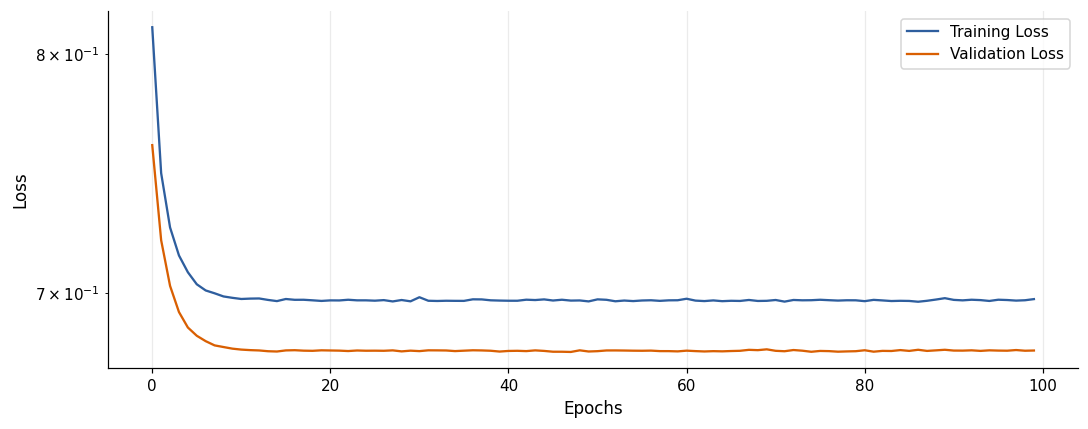

In [30]:
fig = arch.plot_losses()

### 📈 Lendo as curvas como um praticante

- As duas curvas **caem rápido nas primeiras ~10 épocas** e depois estabilizam. O SGD encontrou rapidamente a vizinhança do mínimo e passou apenas a refinar. (Repare que o eixo y está em escala log e o intervalo é curto, então a queda parece suave.)
- Treino e validação andam **coladas**. Um modelo com 8 parâmetros e ~8 mil exemplos não tem capacidade para decorar o dataset. Aqui não há overfitting.
- A curva de validação ficou **ligeiramente abaixo** da de treino. Estranho? Nem tanto. A loss de treino é a média dos mini-batches **ao longo** da época (enquanto o modelo ainda melhora), já a validação é medida com o modelo do fim da época. Além disso, o sorteio do split pode ter deixado a validação um pouco mais "fácil".
- As curvas estabilizam perto de **0.7**, e não perto de zero como nas aulas 3a/3b. Isso NÃO é um bug, e o motivo é profundo. Nos dados sintéticos, o "ruído" era minúsculo (σ=0.1) e o modelo certo era conhecido. Nos dados reais, tudo o que as nossas 7 features não explicam (localização! fotos! decoração! piscina!) vira **erro irredutível**. A loss de validação estabilizada estima exatamente esse teto.

Como a loss está no espaço padronizado, a leitura é elegante: o alvo padronizado tem variância 1, então uma MSE de validação de ~0.7 significa que o modelo explica cerca de 30% da variância dos preços ($R^2 \approx 0.3$). As features físicas do imóvel contam só uma parte da história do preço no Porto. A Seção 7 traduz isso em euros.

# 7. Avaliação honesta: o modelo vence a média dos vizinhos?

Curva de loss bonita não paga as contas da Dona Amélia. Precisamos responder duas perguntas em unidades que ela entenda (**euros**).

1. Qual o erro típico do modelo?
2. O modelo é melhor do que a **Estratégia 1** (chutar a média para todo mundo)?

O baseline da média é o "adversário mínimo": um previsor que ignora as features e responde sempre `y_mu`. Se o nosso modelo não bater isso, o aprendizado não serviu para nada.

In [31]:
# ---------------------------------------------------------------------
# Previsoes na validacao, de volta para euros
# ---------------------------------------------------------------------

# Features padronizadas e alvos reais (em €) do conjunto de validacao
x_val_z = x_tensor_z[val_idx]
y_val   = y_tensor[val_idx]            # em euros

# Modelo preve no espaco padronizado; revertemos com y_mu e y_std
y_pred_z = arch.predict(x_val_z.numpy())
y_pred   = y_pred_z * y_std.item() + y_mu.item()   # de volta para €

y_true = y_val.numpy()

# Baseline ingenuo: prever a MEDIA DO TREINO para todos os anuncios
y_base = np.full_like(y_true, y_mu.item())

def rmse(y_t, y_p): return float(np.sqrt(np.mean((y_t - y_p) ** 2)))
def mae(y_t, y_p):  return float(np.mean(np.abs(y_t - y_p)))

rmse_model, mae_model = rmse(y_true, y_pred), mae(y_true, y_pred)
rmse_base,  mae_base  = rmse(y_true, y_base), mae(y_true, y_base)

print(f"{'':22s}{'RMSE':>10s}{'MAE':>10s}")
print(f"{'Baseline (média)':22s}{rmse_base:>9.2f}€{mae_base:>9.2f}€")
print(f"{'Regressão linear':22s}{rmse_model:>9.2f}€{mae_model:>9.2f}€")
print(f"\nRedução do RMSE em relação ao baseline: {(1 - rmse_model / rmse_base):.1%}")

                            RMSE       MAE
Baseline (média)          51.44€    40.48€
Regressão linear          43.04€    32.96€

Redução do RMSE em relação ao baseline: 16.3%


### 🔍 Traduzindo

- **RMSE** penaliza erros grandes (é a raiz do MSE); **MAE** é o erro absoluto médio, mais fácil de comunicar. "Erramos a diária, tipicamente, em ~€33."
- O modelo **vence o baseline** com folga consistente. As 7 features carregam sinal de verdade.
- Ainda assim, o erro não é desprezível para diárias medianas de ~€120. Coerente com o $R^2 \approx 0.3$ da seção anterior: características físicas explicam parte do preço, e o resto mora em variáveis que não usamos (localização à frente).

Números resumem, gráficos revelam. Vamos **ver** as previsões.

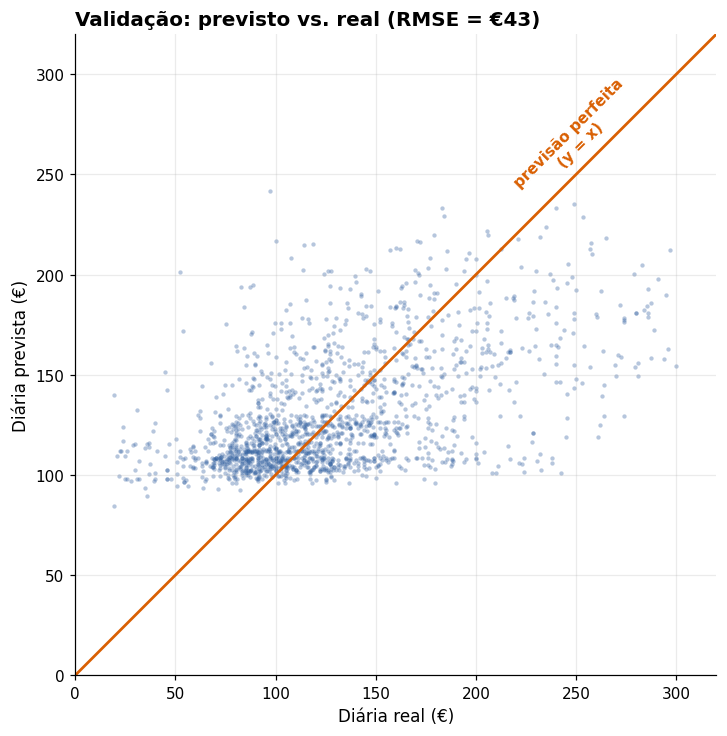

In [32]:
# Previsto vs real na validacao: quanto mais perto da diagonal, melhor
fig, ax = plt.subplots(figsize=(6.8, 6.8))

ax.scatter(y_true, y_pred, s=8, alpha=0.35, color=C_MAIN, linewidths=0)
lims = [0, 320]
ax.plot(lims, lims, color=C_ACCENT, linewidth=1.8)
ax.annotate("previsão perfeita\n(y = x)", xy=(255, 262), color=C_ACCENT,
            fontsize=10, fontweight="bold", rotation=45, ha="center", va="bottom",
            rotation_mode="anchor")

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_title(f"Validação: previsto vs. real (RMSE = €{rmse_model:.0f})")
ax.set_xlabel("Diária real (€)")
ax.set_ylabel("Diária prevista (€)")
plt.tight_layout()
plt.show()

### 🔍 O que a nuvem de pontos revela

- A nuvem **sobe junto com a diagonal**: o modelo aprendeu a tendência.
- Ela é **achatada na vertical**: o modelo raramente prevê abaixo de ~€85 ou acima de ~€240. Modelos lineares com MSE são conservadores, puxando previsões para perto da média. Repare que anúncios baratos tendem a ficar **acima** da diagonal (superprevistos) e os caros, **abaixo** (subprevistos). Esse é um padrão clássico chamado *regressão à média*.

## 7.1 · Abrindo a caixa (nem tão) preta: o que o modelo aprendeu?

Um modelo linear tem uma vantagem preciosa sobre redes profundas: podemos **ler os seus pesos**. Cada peso $w_j$ diz quanto a previsão muda quando a feature $j$ aumenta uma unidade, mantidas as outras fixas.

Só que treinamos no espaço padronizado. Para voltar às unidades originais, usamos

$$\Delta \text{preço por unidade da feature } j = w_j \cdot \frac{\sigma_y}{\sigma_{x_j}}$$

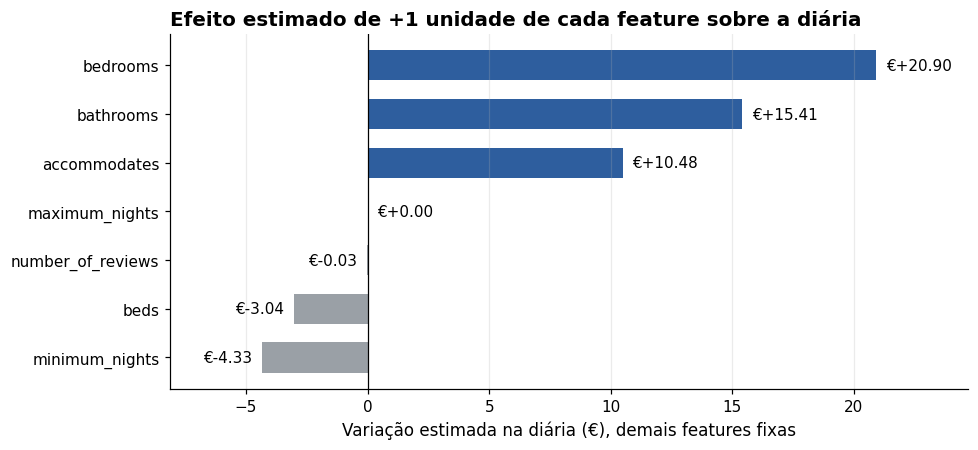

In [33]:
# Extrai pesos do modelo e converte para €/unidade de cada feature
w_z = model[0].weight.detach().cpu().numpy().ravel()   # pesos no espaco padronizado

eur_per_unit = w_z * y_std.item() / std.numpy()        # €/unidade no espaco original

sorted_idx = np.argsort(eur_per_unit)
feats  = [feature_cols[i] for i in sorted_idx]
vals   = eur_per_unit[sorted_idx]

fig, ax = plt.subplots(figsize=(9, 4.2))
colors = [C_MAIN if v >= 0 else C_GRAY for v in vals]
bars = ax.barh(feats, vals, color=colors, height=0.62)
ax.axvline(0, color="black", linewidth=0.8)

for bar, v in zip(bars, vals):
    offset = 0.4 if v >= 0 else -0.4
    ax.annotate(f"€{v:+.2f}", xy=(v + offset, bar.get_y() + bar.get_height()/2),
                va="center", ha="left" if v >= 0 else "right", fontsize=10)

ax.set_title("Efeito estimado de +1 unidade de cada feature sobre a diária")
ax.set_xlabel("Variação estimada na diária (€), demais features fixas")
ax.grid(axis="y", visible=False)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

### 🔍 Lendo os pesos com maturidade

- Quarto extra, banheiro extra e hóspede adicional têm os maiores efeitos positivos estimados sobre a diária.
- 🤯 **O paradoxo das camas.** `beds` tem correlação **+0.40** com o preço (Seção 5), mas recebeu peso **negativo** no modelo! Contradição? Não. O peso mede o efeito de +1 cama **mantendo quartos e hóspedes fixos**. Ou seja, enfiar mais camas num imóvel do mesmo tamanho o move para o mercado "hostel", que cobra menos por noite. Correlação simples e efeito condicional podem até ter sinais opostos. É a multicolinearidade em ação, e este é possivelmente o insight mais valioso da aula.
- O efeito de `maximum_nights` parece zero, mas cuidado com a **unidade**: é o efeito de +1 noite numa coluna que varia aos milhares. Efeito por unidade pequeno não significa coluna irrelevante (embora aqui a correlação ~0 confirme que ela é fraca mesmo).
- ⚠️ **Cuidado com a leitura causal.** Esses números descrevem associações no dataset, condicionadas às outras features do modelo. Por causa da multicolinearidade, o crédito do preço se divide entre features irmãs de forma instável. Reformar o banheiro não garante nada. 😄

✅ **Check yourself**

1. Por que todo modelo precisa ser comparado com um baseline?
2. O que significa, na prática, um MAE de ~€33 para a Dona Amélia?
3. Como uma feature pode ter correlação positiva com o alvo e, ainda assim, peso negativo no modelo?
3. Por que multiplicamos $w_j$ por $\sigma_y / \sigma_{x_j}$ antes de interpretar?

# 8. Salvar, carregar e responder à Dona Amélia

## 8.1 · Checkpoint

Na aula 3a aprendemos que treinar sem salvar é trabalho jogado fora. O checkpoint guarda o estado do modelo, do otimizador e o histórico de losses. Para "produção", também precisaríamos guardar `mu`, `std`, `y_mu` e `y_std`, pois sem eles não conseguimos padronizar entradas novas nem voltar para euros. Vamos salvá-los juntos.

In [34]:
# Salva o checkpoint do treino (mesma receita da aula 3a/3b)
arch.save_checkpoint('porto_model.pth')

# Em producao, as estatisticas de padronizacao sao tao importantes
# quanto os pesos: salvamos tudo em um unico artefato
torch.save({
    'mu': mu, 'std': std,
    'y_mu': y_mu, 'y_std': y_std,
    'feature_cols': feature_cols,
}, 'porto_scaler.pth')

print("Artefatos salvos: porto_model.pth + porto_scaler.pth")

Artefatos salvos: porto_model.pth + porto_scaler.pth


In [35]:
# Simula uma "sessao nova": recria modelo/otimizador e carrega o checkpoint
torch.manual_seed(42)
new_model = nn.Sequential(nn.Linear(D, 1))
new_optimizer = optim.SGD(new_model.parameters(), lr=lr)
new_loss_fn = nn.MSELoss(reduction='mean')

new_arch = Architecture(new_model, new_loss_fn, new_optimizer)
new_arch.load_checkpoint('porto_model.pth')

scaler = torch.load('porto_scaler.pth', weights_only=False)
print(f"Modelo restaurado após {new_arch.total_epochs} épocas de treino")

Modelo restaurado após 100 épocas de treino


## 8.2 · A resposta 🥁

O apartamento da Dona Amélia, na ordem exata de `feature_cols`:

| accommodates | bathrooms | bedrooms | beds | minimum_nights | maximum_nights | number_of_reviews |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 4 | 1 | 2 | 2 | 2 | 365 | 0 |

(`number_of_reviews = 0`, afinal o anúncio é novo.) O fluxo de previsão em produção é sempre o mesmo: **padronizar com as estatísticas do treino → prever → despadronizar**.

In [36]:
# -------------------------------------------------------------
# 1) Monta a entrada NA MESMA ORDEM de feature_cols
# -------------------------------------------------------------
X_new = np.array([[4.0, 1.0, 2.0, 2.0, 2.0, 365.0, 0.0]], dtype=np.float32)

# -------------------------------------------------------------
# 2) Padroniza com as estatisticas DO TREINO (carregadas do artefato)
# -------------------------------------------------------------
X_new_t = torch.as_tensor(X_new)
X_new_norm = (X_new_t - scaler['mu']) / scaler['std']

# -------------------------------------------------------------
# 3) Preve com o modelo restaurado (saida no espaco padronizado)
# -------------------------------------------------------------
y_pred_z = new_arch.predict(X_new_norm.numpy())

# -------------------------------------------------------------
# 4) Reverte a padronizacao do alvo para obter euros
# -------------------------------------------------------------
y_pred_eur = y_pred_z * scaler['y_std'].item() + scaler['y_mu'].item()

print(f"Diária sugerida para a Dona Amélia: €{float(y_pred_eur.squeeze()):.2f}")

Diária sugerida para a Dona Amélia: €143.08


Pronto. Não é um número mágico, e sim uma **referência estatística honesta** baseada em milhares de anúncios reais, com erro típico conhecido (~€33 de MAE). A recomendação profissional para a Dona Amélia combinaria esse valor com o erro do modelo, algo como

> "Anuncie na faixa da previsão ± MAE, comece pelo meio e ajuste conforme a taxa de ocupação."

✅ **Check yourself**

1. Por que salvamos `mu`, `std`, `y_mu` e `y_std` junto com o modelo?
2. O que aconteceria se passássemos as features do apartamento em outra ordem?
3. Se a Dona Amélia acumular 50 avaliações, o modelo mudaria muito a previsão? (Olhe o peso de `number_of_reviews`.)

# 9. 📝 Auto-teste final (recuperação espaçada)

Responda **sem rolar o notebook**. Depois confira. Errar agora e corrigir é o que fixa o conteúdo.

1. Por que a coluna `price` chega como texto, e quais dois caracteres removemos antes do `astype(float)`?
2. Explique a regra do IQR com `k=1.5`. O que acontece com o dataset quando a aplicamos em 8 colunas ao mesmo tempo?
3. Quais duas features mais se correlacionam com o preço no Porto? E qual feature tinha correlação relevante no Rio, mas não aqui?
4. Enuncie a regra de ouro contra data leakage na padronização.
5. Por que a loss de validação estabiliza em ~0.7 aqui, mas chegava perto de 0.01 nas aulas 3a/3b com dados sintéticos?
6. Qual é o baseline mínimo que qualquer modelo de regressão deve vencer, e por quê?
7. Escreva de memória as 4 linhas que treinam o modelo usando a classe `Architecture`.
8. No fluxo de produção, quais são os 3 passos entre receber as features de um imóvel novo e devolver um preço em euros?

<details>
<summary><b>Clique para conferir um gabarito resumido</b></summary>

1. A plataforma formata com símbolo de moeda e separador de milhar; removemos `,` e `$`.
2. Mantemos valores em [Q1 − 1.5·IQR, Q3 + 1.5·IQR]; aplicada em 8 colunas, a interseção das máscaras remove muito mais linhas do que qualquer filtro isolado.
3. `bedrooms` e `accommodates` (~0.50); no Rio, `minimum_nights` (0.17) tinha sinal, no Porto é ~0.
4. Média e desvio calculados apenas no treino e aplicados a todo o resto.
5. Nos dados reais há erro irredutível grande: tudo o que as 7 features não explicam (localização, fotos, qualidade) fica na loss.
6. Prever a média do treino para todos; se o modelo não vence isso, as features não agregaram nada.
7. `arch = Architecture(model, loss_fn, optimizer)` · `arch.set_seed(42)` · `arch.set_loaders(train_loader, val_loader)` · `arch.train(n_epochs=100)`.
8. Padronizar com estatísticas do treino → prever → reverter a padronização do alvo.

</details>

# 10. 🚀 Desafios para praticar

Escolha ao menos dois. Cada um ataca uma decisão que tomamos por você ao longo da aula.

1. **O experimento do caos.** Treine o modelo **sem** padronizar `X` e `y` (valores brutos, `lr=0.001`). O que acontece com a curva de loss? Depois tente reduzir o learning rate até estabilizar. Sua previsão da Seção 6.3 estava certa?
2. **O `k` da discórdia.** Refaça o filtro IQR com `k=3.0`. Quantas linhas sobrevivem? O RMSE em euros melhora ou piora? Por quê?
3. **Localização, localização, localização.** Adicione `latitude` e `longitude` como features e retreine. O RMSE cai? Compare com o mapa da Seção 3.1 e explique por que um modelo **linear** aproveita pouco essas colunas.
4. **Turbine o otimizador.** Troque `optim.SGD` por `optim.Adam` mantendo tudo o mais igual. Compare as curvas de loss nas primeiras 20 épocas.
5. **Só a cidade do Porto.** Filtre `neighbourhood_group_cleansed == "PORTO"` antes do pipeline e retreine. Os pesos em €/unidade mudam? O erro melhora para anúncios do centro?
6. **Feature nova.** Escolha uma coluna do dataset original que não usamos (ex.: `review_scores_rating`) e incorpore ao pipeline, cuidando dos valores ausentes. Ela ajuda?
7. **(Bônus criativo) O anúncio perfeito.** Usando os pesos da Seção 7.1, monte o imóvel "mais caro possível" dentro dos limites do dataset filtrado e estime a diária. O resultado é realista? O que isso ensina sobre extrapolação?

---

<center>

**Fim da Aula 04** 🎓


</center>